In [27]:
import qfi
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

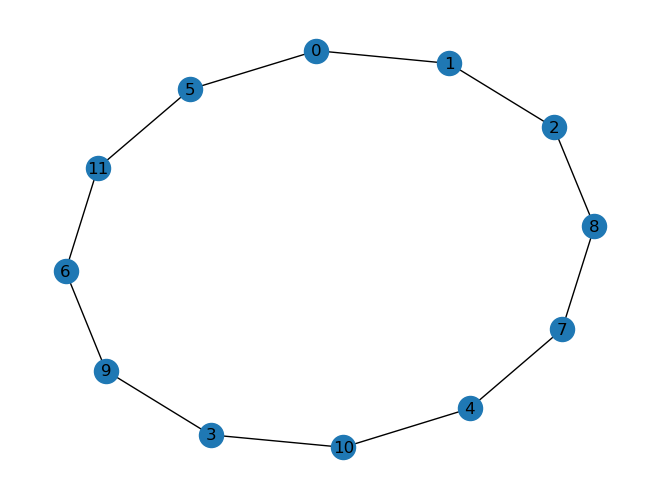

In [17]:
n = 12 # number of qubits (nodes)

# prepare the Hamiltonian for the ring of disagrees
# we can use our function, but let's generate using networkx
# H_diag = qfi.ring_ham_maxcut_diag(n)

G = nx.random_regular_graph(2, n) # 2-regular graph (ring); can be any other graph
H_diag = qfi.edges_to_ham(n, list(G.edges))

nx.draw(G, with_labels=True)

In [32]:
# let's compute the QFIM matrix

p = 12 # number of QAOA layers
pars = np.random.uniform(0, 2*np.pi, 2*p) # random parameters

# some pre-computed entities
d = 2**n # dimensionality
x_list = qfi.mixer_list(n) # list of indices for implementing the X-gate 
state_ini = np.full(d, 1/np.sqrt(d)) # initial state |+>^n

qfim = qfi.qaoa_qfi_matrix(pars, n, x_list, H_diag, state_ini) # compute QFIM

QFIM rank: 12
p_c: 6
n: 12


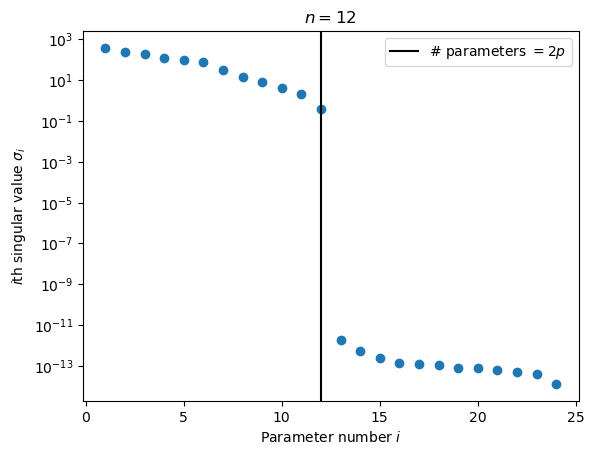

In [49]:
# now we analyze the singular values of QFIM

sigmas = np.linalg.svd(qfim, compute_uv=False, hermitian=True) # find singular values
qfim_rank = np.linalg.matrix_rank(qfim)
p_c = qfim_rank//2 # note that the rank is the number of contributing parameters, so the depth of the QAOA ansatz is the half of that 

print("QFIM rank:", qfim_rank)
print("p_c:", p_c)
print("n:", n)

plt.scatter(np.arange(1, 2*p + 1), sigmas)
plt.axvline(p, color="black", label="# parameters $= 2p$")
plt.xlabel(r"Parameter number $i$")
plt.ylabel(r"$i$th singular value $\sigma_i$")
plt.title(f"$n={n}$")
plt.yscale("log")
plt.legend()
plt.show()